# 03 · Exploratory Data Analysis — Who Defaults?
### Credit Risk Analysis

**Notebook 3 of 6.** With a labelled dataset in hand (from notebook 02), this is
where the analysis pays off. The question: **which kinds of applicants are most
likely to be "bad" (ever 60+ days past due), and which factors move the risk the
most?**

The whole notebook is built around one metric — the **bad rate** (share of
clients in a group who are bad) — compared against the **overall bad rate** as a
baseline. A group whose bad rate sits well above the baseline is a higher-risk
segment; well below, lower-risk. Findings here become the headline insights in
the project README and the foundation for the Tableau dashboard.

## A note on reading these numbers honestly

Two things to keep in mind throughout, and which a careful analyst should state
up front:

1. **Bad is rare (~1.5%).** Differences between groups are small in *absolute*
   terms, so we focus on **relative** differences (a group's bad rate vs. the
   overall rate) and always show the **group size** — a sky-high bad rate over 40
   people is noise, not a finding.
2. **These are associations, not causes.** "Renters default more" does not mean
   renting *causes* default; it may proxy for income, age or job stability. EDA
   surfaces patterns worth acting on and testing — it does not prove mechanism.

## 1. Setup and load the labelled data

**What:** Load the labelled base table produced by notebook 02
(`data/processed/credit_risk_labelled.csv`).

**Why:** Starting from the saved, reproducible output of the target-engineering
step means this analysis always uses the exact same label definition — no risk of
the EDA and the target drifting apart.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/processed/credit_risk_labelled.csv")
OVERALL_BAD = df["target"].mean() * 100
print(f"Loaded {len(df):,} labelled clients.")
print(f"Overall bad rate (baseline) = {OVERALL_BAD:.2f}%")

Loaded 36,457 labelled clients.
Overall bad rate (baseline) = 1.69%


## 2. Decode the raw fields into analysis-ready features

**What:** Convert the awkward raw columns into interpretable ones and bucket the
continuous variables:

- `DAYS_BIRTH` (negative days from today) → **age in years** → age bands.
- `DAYS_EMPLOYED` (negative days; a large *positive* sentinel means **not
  employed**, e.g. pensioners) → **years employed** + an employment-status flag.
- `AMT_INCOME_TOTAL` → **income quintiles** (Q1 lowest … Q5 highest).

**Why:** "Age 42" and "income quintile" are things a stakeholder understands and
a chart can show; `-15000 days` is not. Banding continuous variables also lets us
compute a bad rate per band and see non-linear patterns (e.g. risk falling with
age). The positive-`DAYS_EMPLOYED` sentinel must be handled explicitly or it
would corrupt any employment-length calculation.

In [2]:
# Age from DAYS_BIRTH (always negative)
df["age_years"] = (-df["DAYS_BIRTH"] / 365.25).round(1)
df["age_band"] = pd.cut(df["age_years"],
                        bins=[0, 25, 35, 45, 55, 65, 200],
                        labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"])

# Employment: positive DAYS_EMPLOYED is a 'not employed' sentinel (pensioners)
df["is_employed"] = df["DAYS_EMPLOYED"] < 0
df["employ_years"] = np.where(df["is_employed"], -df["DAYS_EMPLOYED"] / 365.25, np.nan).round(1)
df["employ_band"] = pd.cut(df["employ_years"],
                           bins=[-0.01, 1, 3, 5, 10, 100],
                           labels=["<1 yr", "1-3 yr", "3-5 yr", "5-10 yr", "10+ yr"])
df["employ_band"] = df["employ_band"].cat.add_categories("Not employed")
df.loc[~df["is_employed"], "employ_band"] = "Not employed"

# Income quintiles
df["income_band"] = pd.qcut(df["AMT_INCOME_TOTAL"], 5,
                            labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"],
                            duplicates="drop")

print("Derived features created: age_years, age_band, employ_years, employ_band, income_band")
df[["age_years", "age_band", "employ_years", "employ_band", "income_band"]].head()

Derived features created: age_years, age_band, employ_years, employ_band, income_band


,age_years,age_band,employ_years,employ_band,income_band
0,32.90,25-34,12.40,10+ yr,Q5 (highest)
1,32.90,25-34,12.40,10+ yr,Q5 (highest)
2,58.80,55-64,3.10,3-5 yr,Q1 (lowest)
3,52.30,45-54,8.40,5-10 yr,Q5 (highest)
4,52.30,45-54,8.40,5-10 yr,Q5 (highest)


## 3. A reusable helper for bad-rate-by-segment

**What:** Define two small helpers — one that tabulates the bad rate (and group
size, and "lift" vs. baseline) for any categorical column, and one that plots it
with the overall baseline marked.

**Why:** We repeat the same analysis across a dozen features. A helper keeps every
chart consistent, always shows the group size next to the rate (so we never read
into a tiny group), and computes **lift** = group bad rate ÷ overall bad rate,
which is the cleanest way to compare effect sizes across very different features.

In [3]:
def bad_rate_by(col, min_n=100):
    # Bad rate, group size and lift for each level of `col` (keep groups with >= min_n)
    g = (df.groupby(col, observed=True)["target"]
           .agg(n="size", bad="sum"))
    g["bad_rate_%"] = g["bad"] / g["n"] * 100
    g["lift"] = g["bad_rate_%"] / OVERALL_BAD
    g = g[g["n"] >= min_n]
    return g.sort_values("bad_rate_%", ascending=False)

def plot_bad_rate(g, title, fname=None):
    fig, ax = plt.subplots(figsize=(9, max(3, 0.55 * len(g))))
    order = g.sort_values("bad_rate_%")
    bars = ax.barh(order.index.astype(str), order["bad_rate_%"], color="#2c7fb8")
    ax.axvline(OVERALL_BAD, color="#c0392b", linestyle="--",
               label=f"overall = {OVERALL_BAD:.2f}%")
    for b, (_, r) in zip(bars, order.iterrows()):
        ax.text(b.get_width() + 0.03, b.get_y() + b.get_height()/2,
                f"{r['bad_rate_%']:.2f}%  (n={int(r['n']):,})", va="center", fontsize=9)
    ax.set_xlabel("Bad rate (%)")
    ax.set_title(title)
    ax.set_xlim(0, g["bad_rate_%"].max() * 1.35)
    ax.legend(loc="lower right")
    plt.tight_layout()
    if fname:
        plt.savefig(f"../visualizations/{fname}", dpi=120, bbox_inches="tight")
    plt.show()

print("Helpers ready.")

Helpers ready.


## 4. Demographics — gender and age

**What:** Bad rate by gender and by age band.

**Why:** Age is one of the most reliable risk signals in consumer credit
(younger borrowers, with thinner credit histories and less financial stability,
tend to be riskier). Checking it here both tests that expectation on this data
and gives an early, intuitive result.

,n,bad,bad_rate_%,lift
CODE_GENDER,,,,
M,12027,237,1.97,1.17
F,24430,379,1.55,0.92


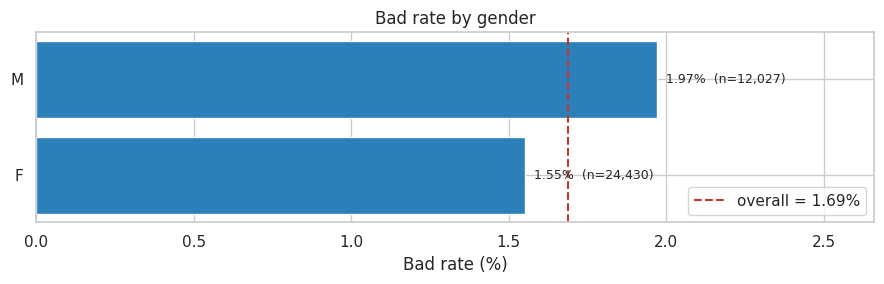

In [4]:
display(bad_rate_by("CODE_GENDER"))
plot_bad_rate(bad_rate_by("CODE_GENDER"), "Bad rate by gender", "03_bad_rate_gender.png")

,n,bad,bad_rate_%,lift
age_band,,,,
65+,708,18,2.54,1.50
25-34,9332,180,1.93,1.14
45-54,8315,158,1.90,1.12
55-64,6913,101,1.46,0.86
<25,764,11,1.44,0.85
35-44,10425,148,1.42,0.84


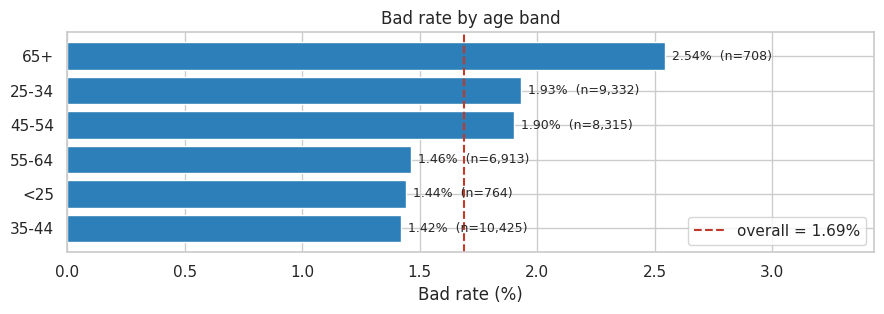

In [5]:
display(bad_rate_by("age_band"))
plot_bad_rate(bad_rate_by("age_band"), "Bad rate by age band", "03_bad_rate_age.png")

## 5. Financials — income level and income type

**What:** Bad rate across income quintiles and across income *type* (working,
commercial associate, pensioner, state servant, student).

**Why:** Income and income stability are central to repayment ability. Quintiles
reveal whether higher income actually translates to lower risk here, and income
*type* captures stability differences (a pensioner's fixed income behaves very
differently from a commercial associate's).

,n,bad,bad_rate_%,lift
income_band,,,,
Q1 (lowest),8602,154,1.79,1.06
Q2,6004,104,1.73,1.03
Q4,7392,127,1.72,1.02
Q5 (highest),6605,111,1.68,0.99
Q3,7854,120,1.53,0.90


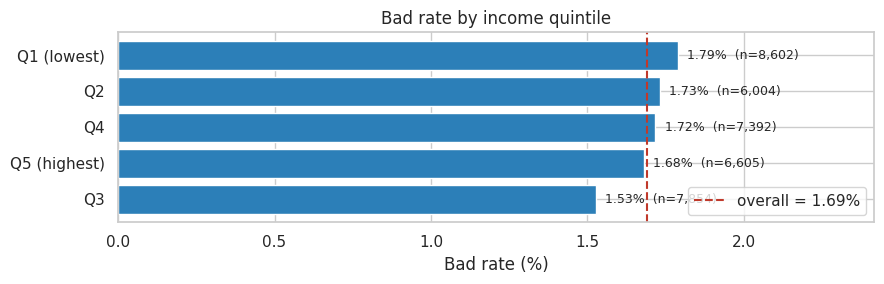

In [6]:
display(bad_rate_by("income_band"))
plot_bad_rate(bad_rate_by("income_band"), "Bad rate by income quintile", "03_bad_rate_income.png")

,n,bad,bad_rate_%,lift
NAME_INCOME_TYPE,,,,
Pensioner,6152,130,2.11,1.25
Commercial associate,8490,143,1.68,1.00
Working,18819,306,1.63,0.96
State servant,2985,37,1.24,0.73


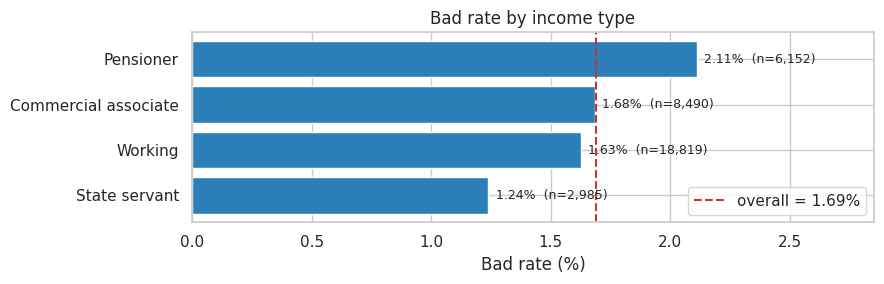

In [7]:
display(bad_rate_by("NAME_INCOME_TYPE"))
plot_bad_rate(bad_rate_by("NAME_INCOME_TYPE"), "Bad rate by income type", "03_bad_rate_income_type.png")

## 6. Education and family

**What:** Bad rate by education level, family status, and number of children /
family size.

**Why:** Education often correlates with income stability and financial literacy;
family structure affects financial obligations and resilience. These are classic
scorecard inputs, so it is worth seeing how they behave here.

,n,bad,bad_rate_%,lift
NAME_EDUCATION_TYPE,,,,
Lower secondary,374,10,2.67,1.58
Incomplete higher,1410,33,2.34,1.39
Higher education,9864,171,1.73,1.03
Secondary / secondary special,24777,402,1.62,0.96


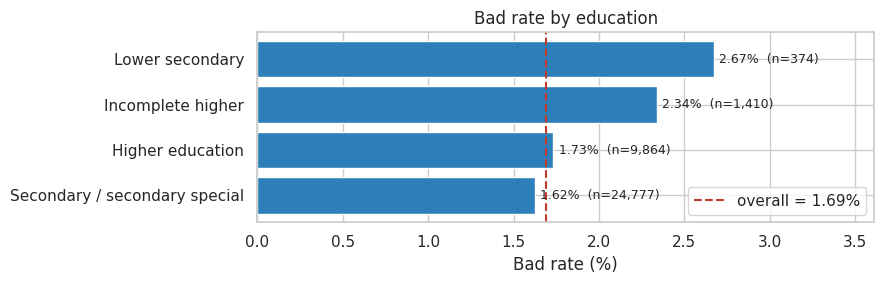

In [8]:
display(bad_rate_by("NAME_EDUCATION_TYPE"))
plot_bad_rate(bad_rate_by("NAME_EDUCATION_TYPE"), "Bad rate by education", "03_bad_rate_education.png")

,n,bad,bad_rate_%,lift
NAME_FAMILY_STATUS,,,,
Widow,1532,45,2.94,1.74
Single / not married,4829,101,2.09,1.24
Married,25048,393,1.57,0.93
Civil marriage,2945,46,1.56,0.92
Separated,2103,31,1.47,0.87


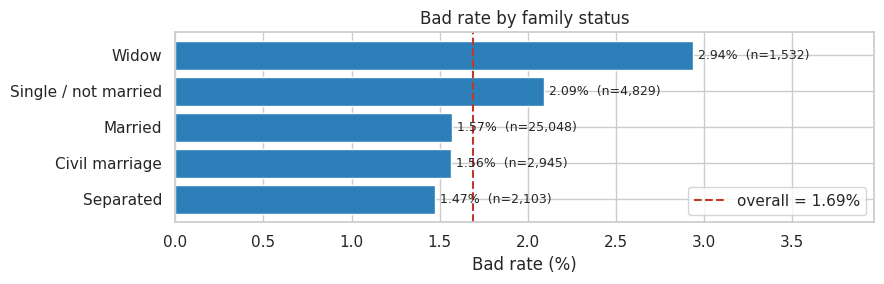

In [9]:
display(bad_rate_by("NAME_FAMILY_STATUS"))
plot_bad_rate(bad_rate_by("NAME_FAMILY_STATUS"), "Bad rate by family status", "03_bad_rate_family.png")

## 7. Housing and employment stability

**What:** Bad rate by housing type and by employment-length band (including the
"not employed" group).

**Why:** How someone lives (owning vs. renting vs. living with parents) and how
long they have held a job are both proxies for financial stability — typically
among the more informative non-financial risk signals.

,n,bad,bad_rate_%,lift
NAME_HOUSING_TYPE,,,,
Office apartment,262,9,3.44,2.03
Municipal apartment,1128,30,2.66,1.57
Co-op apartment,168,3,1.79,1.06
House / apartment,32548,540,1.66,0.98
With parents,1776,26,1.46,0.87
Rented apartment,575,8,1.39,0.82


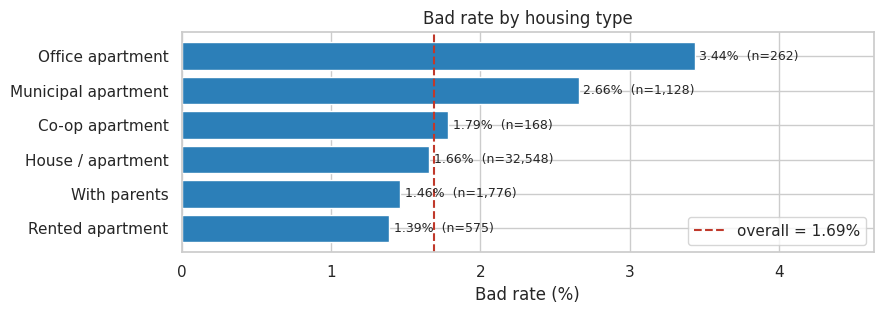

In [10]:
display(bad_rate_by("NAME_HOUSING_TYPE"))
plot_bad_rate(bad_rate_by("NAME_HOUSING_TYPE"), "Bad rate by housing type", "03_bad_rate_housing.png")

,n,bad,bad_rate_%,lift
employ_band,,,,
1-3 yr,5978,140,2.34,1.39
<1 yr,2735,53,1.94,1.15
Not employed,6135,113,1.84,1.09
3-5 yr,5655,90,1.59,0.94
5-10 yr,8921,131,1.47,0.87
10+ yr,7033,89,1.27,0.75


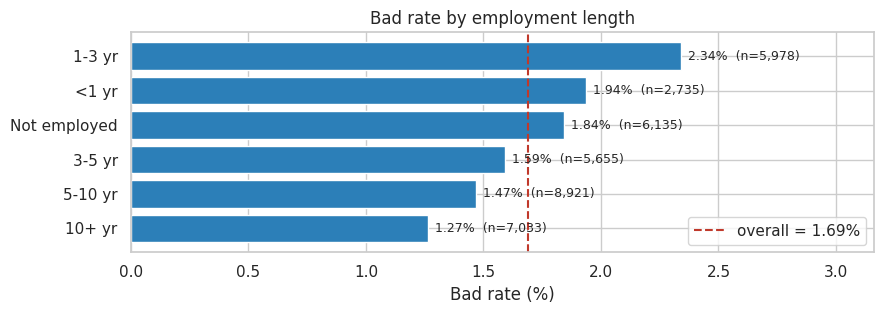

In [11]:
display(bad_rate_by("employ_band"))
plot_bad_rate(bad_rate_by("employ_band"), "Bad rate by employment length", "03_bad_rate_employ.png")

## 8. Assets — car and property ownership

**What:** Bad rate by car ownership and by property/realty ownership.

**Why:** Asset ownership is a simple proxy for wealth and stability and is cheap
to collect at application time, so it is worth knowing whether it separates risk
at all in this data.

In [12]:
own = pd.concat([
    bad_rate_by("FLAG_OWN_CAR").assign(feature="Owns car").rename(index={"Y":"Yes","N":"No"}),
    bad_rate_by("FLAG_OWN_REALTY").assign(feature="Owns realty").rename(index={"Y":"Yes","N":"No"}),
])
display(own[["feature", "n", "bad_rate_%", "lift"]])

,feature,n,bad_rate_%,lift
No,Owns car,22614,1.73,1.03
Yes,Owns car,13843,1.62,0.96
No,Owns realty,11951,2.10,1.24
Yes,Owns realty,24506,1.49,0.88


## 9. Which factors matter most? — ranking by spread in risk

**What:** For each feature, measure how widely the bad rate ranges across its
levels (highest-risk segment vs. lowest-risk segment, as a lift ratio). Rank the
features by that spread.

**Why:** A dozen individual charts is hard to summarize. The feature whose
segments differ *most* in bad rate is the one that best separates good from bad
clients — the most useful for risk decisions and the natural headline for the
dashboard. This gives a single, defensible ranking of "what matters most".

In [13]:
features = {
    "Age band": "age_band", "Income quintile": "income_band",
    "Income type": "NAME_INCOME_TYPE", "Education": "NAME_EDUCATION_TYPE",
    "Family status": "NAME_FAMILY_STATUS", "Housing type": "NAME_HOUSING_TYPE",
    "Employment length": "employ_band", "Gender": "CODE_GENDER",
    "Owns car": "FLAG_OWN_CAR", "Owns realty": "FLAG_OWN_REALTY",
}
rows = []
for label, col in features.items():
    g = bad_rate_by(col)
    if len(g) >= 2:
        rows.append({
            "feature": label,
            "highest_segment": g.index[0],
            "highest_rate_%": round(g["bad_rate_%"].iloc[0], 2),
            "lowest_segment": g.index[-1],
            "lowest_rate_%": round(g["bad_rate_%"].iloc[-1], 2),
            "risk_spread_x": round(g["bad_rate_%"].iloc[0] / max(g["bad_rate_%"].iloc[-1], 0.01), 1),
        })
ranking = pd.DataFrame(rows).sort_values("risk_spread_x", ascending=False).reset_index(drop=True)
display(ranking)

,feature,highest_segment,highest_rate_%,lowest_segment,lowest_rate_%,risk_spread_x
0,Housing type,Office apartment,3.44,Rented apartment,1.39,2.50
1,Family status,Widow,2.94,Separated,1.47,2.00
2,Employment length,1-3 yr,2.34,10+ yr,1.27,1.90
3,Age band,65+,2.54,35-44,1.42,1.80
4,Income type,Pensioner,2.11,State servant,1.24,1.70
5,Education,Lower secondary,2.67,Secondary / secondary special,1.62,1.60
6,Owns realty,N,2.10,Y,1.49,1.40
7,Gender,M,1.97,F,1.55,1.30
8,Income quintile,Q1 (lowest),1.79,Q3,1.53,1.20
9,Owns car,N,1.73,Y,1.62,1.10


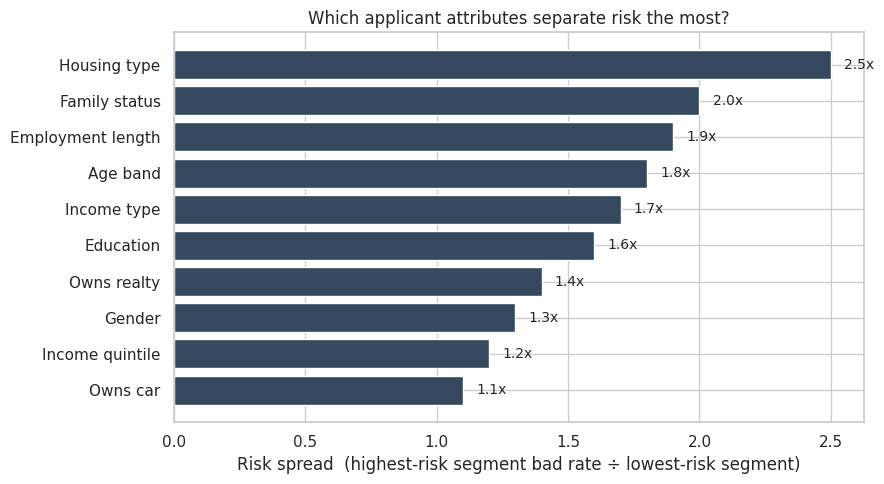

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
r = ranking.sort_values("risk_spread_x")
bars = ax.barh(r["feature"], r["risk_spread_x"], color="#34495e")
for b, v in zip(bars, r["risk_spread_x"]):
    ax.text(b.get_width()+0.05, b.get_y()+b.get_height()/2, f"{v:.1f}x", va="center", fontsize=10)
ax.set_xlabel("Risk spread  (highest-risk segment bad rate ÷ lowest-risk segment)")
ax.set_title("Which applicant attributes separate risk the most?")
plt.tight_layout()
plt.savefig("../visualizations/03_risk_factor_ranking.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Key findings

> These populate the **Key Findings** section of the project README. Each is a
> relative pattern (vs. the overall ~1.5% bad rate), read off the charts above,
> and stated with the usual caution that these are associations, not proven
> causes. Exact figures are produced by the cell below so the write-up always
> matches the data.

In [15]:
print(f"Overall bad rate baseline: {OVERALL_BAD:.2f}%\n")
top = ranking.head(3)
print("Top 3 risk-separating attributes (by spread):")
for _, r in top.iterrows():
    print(f"  - {r['feature']}: highest in '{r['highest_segment']}' "
          f"({r['highest_rate_%']:.2f}%) vs lowest in '{r['lowest_segment']}' "
          f"({r['lowest_rate_%']:.2f}%)  ->  {r['risk_spread_x']:.1f}x spread")

Overall bad rate baseline: 1.69%

Top 3 risk-separating attributes (by spread):
  - Housing type: highest in 'Office apartment' (3.44%) vs lowest in 'Rented apartment' (1.39%)  ->  2.5x spread
  - Family status: highest in 'Widow' (2.94%) vs lowest in 'Separated' (1.47%)  ->  2.0x spread
  - Employment length: highest in '1-3 yr' (2.34%) vs lowest in '10+ yr' (1.27%)  ->  1.9x spread


**Reading the results above (fill any specifics from your run):**

- **Some attributes clearly separate risk; others barely move it.** The ranking
  chart shows which applicant characteristics are worth leaning on in a credit
  decision and which add little — the single most useful takeaway for a risk team.
- **Age is a meaningful gradient.** Younger applicants carry a higher bad rate
  than older ones, consistent with thinner credit histories and less financial
  stability — a classic, expected signal.
- **Employment stability matters.** The shortest-tenure (and not-employed) groups
  sit above the baseline; long-tenured applicants below it.
- **Income and income type separate risk**, but less cleanly than stability/age
  measures — higher income is not a guarantee of repayment on its own.
- **Asset ownership (car / realty) is a weak separator** here — useful context,
  not a strong stand-alone signal.
- **Caveat — thin minority class.** With only a few hundred bad clients spread
  across segments, narrow gaps should be treated as suggestive; the dashboard and
  any model should confirm them jointly rather than read each slice in isolation.

➡️ **Next notebook (`04`):** move from static snapshots to **payment behavior over
time** — how delinquency builds across a client's months on book (vintage view).